<a href="https://colab.research.google.com/github/sujankdk-10/fake_news_detection_ocr/blob/main/dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


WELFake



1. Clean the WELFake Dataset

In [ ]:
import pandas as pd

In [ ]:
# load the raw WELFake file into a table
welfake = pd.read_csv("WELFake_Dataset.csv")
print("Before cleaning:", welfake.shape)

Before cleaning: (72134, 4)


In [ ]:
# remove rows that have no text or no label (they are useless to us)
welfake = welfake.dropna(subset=['text', 'label'])

# remove duplicate articles so the same one can't appear in both train and test
welfake = welfake.drop_duplicates(subset=['text'])

In [ ]:
# join the title and the article text into one column called "content"
welfake['content'] = welfake['title'].fillna('') + " " + welfake['text'].fillna('')

In [ ]:
# this file had 0=real, 1=fake by mistake, so flip it to 1=real, 0=fake
welfake['label'] = 1 - welfake['label']

In [ ]:
print("After cleaning:", welfake.shape)
print(welfake['label'].value_counts())

After cleaning: (62718, 5)
label
1    34620
0    28098
Name: count, dtype: int64


In [ ]:
# save the cleaned data to a new file
welfake.to_csv("welfake_clean.csv", index=False)

2. Load the Cleaned Data

In [ ]:
import pandas as pd

# load the cleaned file back in
welfake = pd.read_csv("welfake_clean.csv")
welfake.shape

(62718, 5)

3. Split the Data (Train / Validation / Test)

In [ ]:
from sklearn.model_selection import train_test_split

X = welfake['content']      # the text (input)
y = welfake['label']        # the label (answer): 1=real, 0=fake

# First split: 70% train, 30% temporary (to be split again)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: divide that 30% into 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# stratify keeps the same real/fake ratio in every part
# random_state=42 makes the split the same every time it runs

print("Train:", X_train.shape[0])
print("Validation:", X_val.shape[0])
print("Test:", X_test.shape[0])

Train: 43902
Validation: 9408
Test: 9408


4. Classical Baseline 1 — Logistic Regression

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# turn the text into numbers using TF-IDF (scores words by importance)
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# train the Logistic Regression model on the training numbers
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# predict on the test set and check how well it did
lr_preds = lr.predict(X_test_tfidf)
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print("F1 score:", f1_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

Logistic Regression
Accuracy: 0.9431335034013606
F1 score: 0.9486416434674091
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      4215
           1       0.95      0.95      0.95      5193

    accuracy                           0.94      9408
   macro avg       0.94      0.94      0.94      9408
weighted avg       0.94      0.94      0.94      9408



5. Classical Baseline 2 — Linear SVM

In [ ]:
from sklearn.svm import LinearSVC

# Reuse the same TF-IDF features from before
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

# predict on the test set and check the scores
svm_preds = svm.predict(X_test_tfidf)
print("Linear SVM")
print("Accuracy:", accuracy_score(y_test, svm_preds))
print("F1 score:", f1_score(y_test, svm_preds))
print(classification_report(y_test, svm_preds))

Linear SVM
Accuracy: 0.9472789115646258
F1 score: 0.9521604938271605
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4215
           1       0.95      0.95      0.95      5193

    accuracy                           0.95      9408
   macro avg       0.95      0.95      0.95      9408
weighted avg       0.95      0.95      0.95      9408



In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())

GPU available: True


6. Reload Data and Take a Smaller Subset

In [ ]:
import pandas as pd
welfake = pd.read_csv("welfake_clean.csv")
welfake.shape

(62718, 5)

In [ ]:
from sklearn.model_selection import train_test_split

# Take a balanced 20,000-row subset for faster training
welfake_sub = welfake.sample(n=20000, random_state=42)

X = welfake_sub['content']
y = welfake_sub['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

Train: 14000 Val: 3000 Test: 3000


7. Prepare the Text for DistilBERT (Tokenising)

In [ ]:
!pip install -q transformers datasets

In [ ]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Convert text to token IDs the model understands
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=256)
val_encodings   = tokenizer(list(X_val),   truncation=True, padding=True, max_length=256)
test_encodings  = tokenizer(list(X_test),  truncation=True, padding=True, max_length=256)

print("Tokenising done")

Tokenising done


8. Package the Data for the Trainer

In [ ]:
import torch

# this wraps each tokenised article together with its label,
# in the format the trainer needs to read them one at a time
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = NewsDataset(train_encodings, list(y_train))
val_dataset   = NewsDataset(val_encodings,   list(y_val))
test_dataset  = NewsDataset(test_encodings,  list(y_test))

print("Datasets ready:", len(train_dataset), len(val_dataset), len(test_dataset))

Datasets ready: 14000 3000 3000


9. Set Up DistilBERT and the Training Settings

In [ ]:
from transformers import DistilBertForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

# Load DistilBERT with a classification head (2 classes: real/fake)
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2)

# tells the trainer to report accuracy and F1 while training
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

# Training settings
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    logging_steps=100,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Trainer ready")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer ready


10. Fine-tune DistilBERT (the actual training)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.047848,0.030699,0.990667,0.991581
2,0.014397,0.042648,0.991667,0.992486


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1750, training_loss=0.0532014765058245, metrics={'train_runtime': 941.3987, 'train_samples_per_second': 29.743, 'train_steps_per_second': 1.859, 'total_flos': 1854543581184000.0, 'train_loss': 0.0532014765058245, 'epoch': 2.0})

In [ ]:
trainer.save_model('/content/drive/MyDrive/fyp_models/welfake_distilbert')
print("WELFake DistilBERT saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

WELFake DistilBERT saved


11. Final Test on Unseen Data

In [ ]:
test_results = trainer.evaluate(test_dataset)
print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.014397,0.058662,2,0.988000,0.989150


{'eval_loss': 0.05866182595491409, 'eval_accuracy': 0.988, 'eval_f1': 0.9891500904159132}


12. Try the Model on My Own Text

In [ ]:
def predict(text):
    inputs = tokenizer(text, truncation=True, padding=True,
                       max_length=256, return_tensors="pt").to(model.device)
    outputs = model(**inputs)
    pred = outputs.logits.argmax(-1).item()
    label = "REAL" if pred == 1 else "FAKE"
    return label


print(predict("The government announced a new economic policy today."))
print(predict("SHOCKING!!! Aliens spotted controlling the White House, insiders confirm!!!"))

REAL
FAKE


In [ ]:
predict("Elon musk has started war against Trump")

'FAKE'

In [ ]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()
print("Memory cleared")

Memory cleared


Fine-tune BERT


In [ ]:
from transformers import BertTokenizerFast, BertForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import torch

# load BERT's tokeniser (bert-base-uncased, ignores capital letters)
bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# turn the text into tokens BERT can read
# truncation = cut long articles, padding = equal length, max_length = cap at 256
train_enc_bert = bert_tokenizer(list(X_train), truncation=True, padding=True, max_length=256)
val_enc_bert   = bert_tokenizer(list(X_val),   truncation=True, padding=True, max_length=256)
test_enc_bert  = bert_tokenizer(list(X_test),  truncation=True, padding=True, max_length=256)

# wrap each tokenised article with its label, in the format the trainer needs
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])   # attach the correct answer
        return item
    def __len__(self):
        return len(self.labels)

train_ds_bert = NewsDataset(train_enc_bert, list(y_train))
val_ds_bert   = NewsDataset(val_enc_bert,   list(y_val))
test_ds_bert  = NewsDataset(test_enc_bert,  list(y_test))

# load pre-trained BERT with a real/fake classification head (2 classes)
bert_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# report accuracy and F1 during training
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {"accuracy": accuracy_score(labels, preds), "f1": f1_score(labels, preds)}

# training settings: 2 passes over the data, 16 articles at a time
bert_args = TrainingArguments(
    output_dir="./results_bert",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",          # check on validation after each pass
    logging_steps=100,
    report_to="none"
)

# bundle the model, settings, and data together
bert_trainer = Trainer(
    model=bert_model,
    args=bert_args,
    train_dataset=train_ds_bert,
    eval_dataset=val_ds_bert,
    compute_metrics=compute_metrics
)

print("BERT trainer ready")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT trainer ready


In [ ]:
# fine-tune BERT on the fake-news data
bert_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.046184,0.044510,0.987667,0.988925
2,0.028925,0.044838,0.990000,0.990980


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1750, training_loss=0.06090823071343558, metrics={'train_runtime': 2237.9994, 'train_samples_per_second': 12.511, 'train_steps_per_second': 0.782, 'total_flos': 3683554775040000.0, 'train_loss': 0.06090823071343558, 'epoch': 2.0})

In [ ]:
bert_trainer.save_model('/content/drive/MyDrive/fyp_models/welfake_bert')
print("WELFake BERT saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

WELFake BERT saved


In [ ]:
# check BERT on the sealed test set for the true final score
bert_results = bert_trainer.evaluate(test_ds_bert)
print("BERT test results:", bert_results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.028925,0.053336,2,0.988667,0.989784


BERT test results: {'eval_loss': 0.05333602800965309, 'eval_accuracy': 0.9886666666666667, 'eval_f1': 0.9897836538461539}


Fine-tune RoBERTa

In [ ]:
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import torch

# load RoBERTa's tokeniser
roberta_tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

# turn the text into tokens RoBERTa can read
train_enc_rob = roberta_tokenizer(list(X_train), truncation=True, padding=True, max_length=256)
val_enc_rob   = roberta_tokenizer(list(X_val),   truncation=True, padding=True, max_length=256)
test_enc_rob  = roberta_tokenizer(list(X_test),  truncation=True, padding=True, max_length=256)

# wrap each tokenised article with its label, in the format the trainer needs
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])   # attach the correct answer
        return item
    def __len__(self):
        return len(self.labels)

train_ds_rob = NewsDataset(train_enc_rob, list(y_train))
val_ds_rob   = NewsDataset(val_enc_rob,   list(y_val))
test_ds_rob  = NewsDataset(test_enc_rob,  list(y_test))

# load pre-trained RoBERTa with a real/fake classification head (2 classes)
roberta_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

# report accuracy and F1 during training
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {"accuracy": accuracy_score(labels, preds), "f1": f1_score(labels, preds)}

# training settings: 2 passes over the data, 16 articles at a time
roberta_args = TrainingArguments(
    output_dir="./results_roberta",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",          # check on validation after each pass
    logging_steps=100,
    report_to="none"
)

# bundle the model, settings, and data together
roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_args,
    train_dataset=train_ds_rob,
    eval_dataset=val_ds_rob,
    compute_metrics=compute_metrics
)

print("RoBERTa trainer ready")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa trainer ready


In [ ]:
# fine-tune RoBERTa on the fake-news data
roberta_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.168808,0.138521,0.959000,0.962305
2,0.152246,0.160949,0.961000,0.964727
3,0.093427,0.105612,0.965000,0.968249


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2625, training_loss=0.17486545907883416, metrics={'train_runtime': 2613.6301, 'train_samples_per_second': 16.07, 'train_steps_per_second': 1.004, 'total_flos': 5525332162560000.0, 'train_loss': 0.17486545907883416, 'epoch': 3.0})

In [ ]:
roberta_trainer.save_model('/content/drive/MyDrive/fyp_models/welfake_roberta')
print("WELFake RoBERTa (3-epoch) saved properly")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

WELFake RoBERTa (3-epoch) saved properly


In [ ]:
# check RoBERTa on the sealed test set for the honest final score
roberta_results = roberta_trainer.evaluate(test_ds_rob)
print("RoBERTa test results:", roberta_results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.141132,0.129325,3,0.952333,0.956068


RoBERTa test results: {'eval_loss': 0.1293254941701889, 'eval_accuracy': 0.9523333333333334, 'eval_f1': 0.9560675883256529}


ISOT

In [ ]:
true = pd.read_csv("True.csv")
fake = pd.read_csv("Fake.csv")

In [ ]:
true['label'] = 1     # real
fake['label'] = 0     # fake

In [ ]:
isot = pd.concat([true, fake], ignore_index=True)
print("Before cleaning:", isot.shape)

Before cleaning: (44898, 5)


In [ ]:
isot = isot.dropna(subset=['text', 'label'])
isot = isot.drop_duplicates(subset=['text'])
isot['content'] = isot['title'].fillna('') + " " + isot['text'].fillna('')

In [ ]:
print("After cleaning:", isot.shape)
print(isot['label'].value_counts())

After cleaning: (38646, 6)
label
1    21192
0    17454
Name: count, dtype: int64


In [ ]:
isot.to_csv("isot_clean.csv", index=False)

In [ ]:
import pandas as pd
isot = pd.read_csv("isot_clean.csv")
print(isot.shape)
isot['label'].value_counts()

(38646, 6)


,count
label,
1,21192
0,17454


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

# split
X = isot['content']
y = isot['label']
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)
print("ISOT Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print("F1:", f1_score(y_test, lr_preds))

# Linear SVM
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)
svm_preds = svm.predict(X_test_tfidf)
print("ISOT Linear SVM")
print("Accuracy:", accuracy_score(y_test, svm_preds))
print("F1:", f1_score(y_test, svm_preds))

ISOT Logistic Regression
Accuracy: 0.9860272554769709
F1: 0.987329892069451
ISOT Linear SVM
Accuracy: 0.9922373641538726
F1: 0.9929433903089226


In [ ]:
!pip install -q transformers datasets

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import torch

# take a 20,000 subset (same as WELFake) and split
isot_sub = isot.sample(n=20000, random_state=42)
X = isot_sub['content']
y = isot_sub['label']
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# tokenise
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
train_enc = tokenizer(list(X_train), truncation=True, padding=True, max_length=256)
val_enc   = tokenizer(list(X_val),   truncation=True, padding=True, max_length=256)
test_enc  = tokenizer(list(X_test),  truncation=True, padding=True, max_length=256)

# package
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_ds = NewsDataset(train_enc, list(y_train))
val_ds   = NewsDataset(val_enc,   list(y_val))
test_ds  = NewsDataset(test_enc,  list(y_test))

# model + trainer
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {"accuracy": accuracy_score(labels, preds), "f1": f1_score(labels, preds)}

args = TrainingArguments(
    output_dir="./isot_distilbert",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    logging_steps=100,
    report_to="none"
)

distil_isot_trainer = Trainer(
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

print("ISOT DistilBERT trainer ready")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ISOT DistilBERT trainer ready


In [ ]:
distil_isot_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.010373,0.009977,0.998667,0.998783
2,0.001365,0.011521,0.998333,0.998482


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1750, training_loss=0.008360375311092606, metrics={'train_runtime': 810.4295, 'train_samples_per_second': 34.55, 'train_steps_per_second': 2.159, 'total_flos': 1854543581184000.0, 'train_loss': 0.008360375311092606, 'epoch': 2.0})

In [ ]:
distil_isot_results = distil_isot_trainer.evaluate(test_ds)
print("ISOT DistilBERT test:", distil_isot_results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.001365,0.002477,2,0.999667,0.999696


ISOT DistilBERT test: {'eval_loss': 0.0024770956952124834, 'eval_accuracy': 0.9996666666666667, 'eval_f1': 0.9996963255390222}


In [ ]:
# check no test articles appear in training
overlap = set(X_train) & set(X_test)
print("Overlapping articles:", len(overlap))

Overlapping articles: 0


In [ ]:
from transformers import BertTokenizerFast, BertForSequenceClassification
import torch

bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
train_enc_b = bert_tokenizer(list(X_train), truncation=True, padding=True, max_length=256)
val_enc_b   = bert_tokenizer(list(X_val),   truncation=True, padding=True, max_length=256)
test_enc_b  = bert_tokenizer(list(X_test),  truncation=True, padding=True, max_length=256)

train_ds_b = NewsDataset(train_enc_b, list(y_train))
val_ds_b   = NewsDataset(val_enc_b,   list(y_val))
test_ds_b  = NewsDataset(test_enc_b,  list(y_test))

bert_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

bert_args = TrainingArguments(
    output_dir="./isot_bert",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    logging_steps=100,
    report_to="none"
)

bert_isot_trainer = Trainer(
    model=bert_model, args=bert_args,
    train_dataset=train_ds_b, eval_dataset=val_ds_b,
    compute_metrics=compute_metrics
)
print("ISOT BERT trainer ready")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ISOT BERT trainer ready


In [ ]:
bert_isot_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.007532,0.006723,0.999000,0.999088
2,0.004685,0.006613,0.999000,0.999088


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1750, training_loss=0.008146366951188871, metrics={'train_runtime': 1903.0488, 'train_samples_per_second': 14.713, 'train_steps_per_second': 0.92, 'total_flos': 3683554775040000.0, 'train_loss': 0.008146366951188871, 'epoch': 2.0})

In [ ]:
bert_isot_results = bert_isot_trainer.evaluate(test_ds_b)
print("ISOT BERT test:", bert_isot_results)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.004685,0.000056,2,1.000000,1.000000


ISOT BERT test: {'eval_loss': 5.6374541600234807e-05, 'eval_accuracy': 1.0, 'eval_f1': 1.0}


In [ ]:
overlap = set(X_train) & set(X_test)
print("Train/test overlapping articles:", len(overlap))

Train/test overlapping articles: 0


In [ ]:
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
import torch

roberta_tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")
train_enc_r = roberta_tokenizer(list(X_train), truncation=True, padding=True, max_length=256)
val_enc_r   = roberta_tokenizer(list(X_val),   truncation=True, padding=True, max_length=256)
test_enc_r  = roberta_tokenizer(list(X_test),  truncation=True, padding=True, max_length=256)

train_ds_r = NewsDataset(train_enc_r, list(y_train))
val_ds_r   = NewsDataset(val_enc_r,   list(y_val))
test_ds_r  = NewsDataset(test_enc_r,  list(y_test))

roberta_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

roberta_args = TrainingArguments(
    output_dir="./isot_roberta",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    logging_steps=100,
    report_to="none"
)

roberta_isot_trainer = Trainer(
    model=roberta_model, args=roberta_args,
    train_dataset=train_ds_r, eval_dataset=val_ds_r,
    compute_metrics=compute_metrics
)
print("ISOT RoBERTa trainer ready")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ISOT RoBERTa trainer ready


In [ ]:
roberta_isot_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.010162,0.011105,0.998333,0.998479
2,0.017900,0.012150,0.998333,0.998479


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1750, training_loss=0.020215743190475872, metrics={'train_runtime': 2255.4862, 'train_samples_per_second': 12.414, 'train_steps_per_second': 0.776, 'total_flos': 3683554775040000.0, 'train_loss': 0.020215743190475872, 'epoch': 2.0})

In [ ]:
roberta_isot_results = roberta_isot_trainer.evaluate(test_ds_r)
print("ISOT RoBERTa test:", roberta_isot_results)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.017900,0.009801,2,0.998667,0.998784


ISOT RoBERTa test: {'eval_loss': 0.009801371023058891, 'eval_accuracy': 0.9986666666666667, 'eval_f1': 0.9987841945288753}


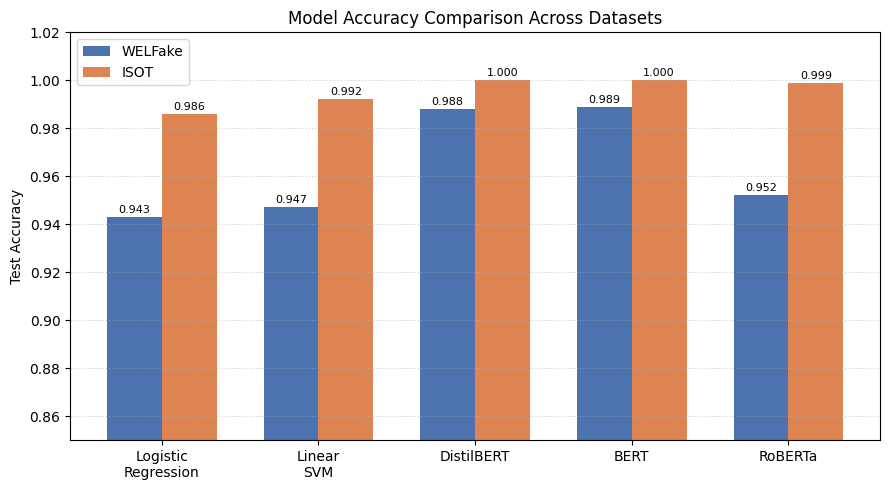

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic\nRegression', 'Linear\nSVM', 'DistilBERT', 'BERT', 'RoBERTa']
welfake = [0.943, 0.947, 0.988, 0.989, 0.952]    # RoBERTa now 0.952 (3-epoch)
isot    = [0.986, 0.992, 1.000, 1.000, 0.999]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, welfake, width, label='WELFake', color='#4C72B0')
bars2 = ax.bar(x + width/2, isot, width, label='ISOT', color='#DD8452')

ax.set_ylabel('Test Accuracy')
ax.set_title('Model Accuracy Comparison Across Datasets')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.6)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x()+bar.get_width()/2, h),
                    xytext=(0,3), textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
bert_isot_trainer.save_model('/content/drive/MyDrive/fyp_models/isot_bert')
distil_isot_trainer.save_model('/content/drive/MyDrive/fyp_models/isot_distilbert')
roberta_isot_trainer.save_model('/content/drive/MyDrive/fyp_models/isot_roberta')
print("ISOT models saved to Drive")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ISOT models saved to Drive


##RQ2: OCR Noise Experiment

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###for WELFake

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

welfake = pd.read_csv("welfake_clean.csv")
welfake_sub = welfake.sample(n=20000, random_state=42)
X = welfake_sub['content']
y = welfake_sub['label']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)
print("Test set size:", len(X_test))

Test set size: 3000


In [ ]:
import random
import string

def add_noise(text, noise_level):
    """
    Corrupt a percentage of characters to simulate OCR errors.
    noise_level = fraction of characters to alter (e.g. 0.10 = 10%)
    Applies substitution, insertion, and deletion.
    """
    if noise_level == 0:
        return text

    chars = list(text)
    n_noisy = int(len(chars) * noise_level)   # how many characters to corrupt
    # pick random positions to corrupt
    positions = random.sample(range(len(chars)), min(n_noisy, len(chars)))

    for pos in positions:
        operation = random.choice(['substitute', 'insert', 'delete'])
        if operation == 'substitute':
            chars[pos] = random.choice(string.ascii_letters)   # swap for a random letter
        elif operation == 'insert':
            chars[pos] = chars[pos] + random.choice(string.ascii_letters)  # add a letter
        elif operation == 'delete':
            chars[pos] = ''   # remove the character

    return ''.join(chars)

In [ ]:
sample = "The government announced a new economic policy today."
print("Clean:  ", sample)
print("5%:     ", add_noise(sample, 0.05))
print("10%:    ", add_noise(sample, 0.10))
print("20%:    ", add_noise(sample, 0.20))

Clean:   The government announced a new economic policy today.
5%:      The governmeJnt announcedTa new economic policy today.
10%:     The governmenHt anuned a new economic polikcy today.
20%:     Te governmeTPkannounceda new ePconooic pocy todayJ.


In [ ]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast

distil_model = DistilBertForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/fyp_models/welfake_distilbert')
distil_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
print("DistilBERT reloaded")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DistilBERT reloaded


In [ ]:
import torch
from sklearn.metrics import accuracy_score, f1_score

def evaluate_at_noise(model, tokenizer, texts, labels, noise_level, batch_size=32):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # apply noise to every test article
    noisy_texts = [add_noise(t, noise_level) for t in texts]

    preds = []
    for i in range(0, len(noisy_texts), batch_size):
        batch = noisy_texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding=True,
                        max_length=256, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model(**enc)
        preds.extend(out.logits.argmax(-1).cpu().numpy())

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    return acc, f1

In [ ]:
labels_list = list(y_test)
texts_list = list(X_test)

acc, f1 = evaluate_at_noise(distil_model, distil_tokenizer, texts_list, labels_list, 0.10)
print(f"DistilBERT at 10% noise: accuracy={acc:.4f}, f1={f1:.4f}")

DistilBERT at 10% noise: accuracy=0.6383, f1=0.5154


In [ ]:
noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20]

print("DistilBERT degradation:")
for nl in noise_levels:
    acc, f1 = evaluate_at_noise(distil_model, distil_tokenizer, texts_list, labels_list, nl)
    print(f"  Noise {int(nl*100):2d}%: accuracy={acc:.4f}, f1={f1:.4f}")

DistilBERT degradation:
  Noise  0%: accuracy=0.9880, f1=0.9892
  Noise  5%: accuracy=0.8090, f1=0.7917
  Noise 10%: accuracy=0.6440, f1=0.5266
  Noise 15%: accuracy=0.5383, f1=0.2857
  Noise 20%: accuracy=0.4940, f1=0.1595


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# retrain classical models (fast, CPU)
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
lr = LogisticRegression(max_iter=1000).fit(X_train_tfidf, y_train)
svm = LinearSVC().fit(X_train_tfidf, y_train)
print("Classical models ready")

Classical models ready


In [ ]:
import pandas as pd
from transformers import (DistilBertForSequenceClassification, DistilBertTokenizerFast,
                          BertForSequenceClassification, BertTokenizerFast,
                          RobertaForSequenceClassification, RobertaTokenizerFast)

noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20]
texts_list = list(X_test)
labels_list = list(y_test)

# --- transformer models: reload from Drive ---
transformers_info = {
    "DistilBERT": (DistilBertForSequenceClassification, DistilBertTokenizerFast,
                   '/content/drive/MyDrive/fyp_models/welfake_distilbert', "distilbert-base-uncased"),
    "BERT":       (BertForSequenceClassification, BertTokenizerFast,
                   '/content/drive/MyDrive/fyp_models/welfake_bert', "bert-base-uncased"),
    "RoBERTa":    (RobertaForSequenceClassification, RobertaTokenizerFast,
                   '/content/drive/MyDrive/fyp_models/welfake_roberta', "roberta-base"),
}

results = []

# classical models (TF-IDF based)
for name, clf in [("Logistic Regression", lr), ("Linear SVM", svm)]:
    for nl in noise_levels:
        noisy = [add_noise(t, nl) for t in texts_list]
        preds = clf.predict(vectorizer.transform(noisy))
        results.append({"Model": name, "Noise": int(nl*100),
                        "Accuracy": accuracy_score(labels_list, preds),
                        "F1": f1_score(labels_list, preds)})
    print(f"{name} done")

# transformer models
for name, (ModelClass, TokClass, path, tok_name) in transformers_info.items():
    model = ModelClass.from_pretrained(path)
    tokenizer = TokClass.from_pretrained(tok_name)
    for nl in noise_levels:
        acc, f1 = evaluate_at_noise(model, tokenizer, texts_list, labels_list, nl)
        results.append({"Model": name, "Noise": int(nl*100), "Accuracy": acc, "F1": f1})
    print(f"{name} done")
    del model
    import gc, torch; gc.collect(); torch.cuda.empty_cache()   # free memory

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Logistic Regression done
Linear SVM done


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT done


Loading weights:   0%|          | 0/201 [00:02<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT done


OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/content/drive/MyDrive/fyp_models/welfake_roberta'. Use `repo_type` argument if needed.

In [ ]:
import os
folder = '/content/drive/MyDrive/fyp_models/'
print(os.listdir(folder))

['bert', 'roberta', 'isot_bert', 'isot_distilbert', 'isot_roberta', 'welfake_distilbert', 'welfake_bert']


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/fyp_models/roberta'))

['config.json', 'model.safetensors', 'training_args.bin']


In [ ]:
print(type(roberta_trainer))

NameError: name 'roberta_trainer' is not defined

In [ ]:
from transformers import RobertaForSequenceClassification, RobertaTokenizerFast
rob_model = RobertaForSequenceClassification.from_pretrained('/content/drive/MyDrive/fyp_models/roberta')
rob_tok = RobertaTokenizerFast.from_pretrained("roberta-base")

# check clean accuracy to identify which version it is
acc, f1 = evaluate_at_noise(rob_model, rob_tok, texts_list, labels_list, 0.0)
print(f"roberta folder clean accuracy: {acc:.4f}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

roberta folder clean accuracy: 0.9270


In [ ]:
import pandas as pd
print(pd.DataFrame(results)['Model'].unique())

['Logistic Regression' 'Linear SVM' 'DistilBERT' 'BERT']


In [ ]:
noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20]
from transformers import RobertaTokenizerFast
rob_model = roberta_trainer.model
rob_tok = RobertaTokenizerFast.from_pretrained("roberta-base")

for nl in noise_levels:
    acc, f1 = evaluate_at_noise(rob_model, rob_tok, texts_list, labels_list, nl)
    results.append({"Model": "RoBERTa", "Noise": int(nl*100), "Accuracy": acc, "F1": f1})
    print(f"RoBERTa {int(nl*100)}% done")

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

RoBERTa 0% done
RoBERTa 5% done
RoBERTa 10% done
RoBERTa 15% done
RoBERTa 20% done
              Model  Noise  Accuracy       F1
Logistic Regression      0  0.930000 0.936709
Logistic Regression      5  0.918000 0.924447
Logistic Regression     10  0.896000 0.902378
Logistic Regression     15  0.851333 0.854058
Logistic Regression     20  0.810333 0.803182
         Linear SVM      0  0.937667 0.943894
         Linear SVM      5  0.914333 0.920850
         Linear SVM     10  0.881333 0.886335
         Linear SVM     15  0.825333 0.823450
         Linear SVM     20  0.768667 0.751076
         DistilBERT      0  0.988000 0.989150
         DistilBERT      5  0.815667 0.800433
         DistilBERT     10  0.637333 0.513417
         DistilBERT     15  0.541333 0.293634
         DistilBERT     20  0.490000 0.147157
               BERT      0  0.988667 0.989784
               BERT      5  0.869000 0.866008
               BERT     10  0.711333 0.648253
               BERT     15  0.585000 0.4017

###for ISOT

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

isot = pd.read_csv("isot_clean.csv")
isot_sub = isot.sample(n=20000, random_state=42)
Xi = isot_sub['content']; yi = isot_sub['label']
Xi_train, Xi_temp, yi_train, yi_temp = train_test_split(Xi, yi, test_size=0.30, stratify=yi, random_state=42)
Xi_val, Xi_test, yi_val, yi_test = train_test_split(Xi_temp, yi_temp, test_size=0.50, stratify=yi_temp, random_state=42)
print("ISOT test size:", len(Xi_test))

ISOT test size: 3000


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

isot_vec = TfidfVectorizer(max_features=5000, stop_words='english')
Xi_train_tfidf = isot_vec.fit_transform(Xi_train)
isot_lr = LogisticRegression(max_iter=1000).fit(Xi_train_tfidf, yi_train)
isot_svm = LinearSVC().fit(Xi_train_tfidf, yi_train)
print("ISOT classical ready")

ISOT classical ready


In [ ]:
isot_texts = list(Xi_test); isot_labels = list(yi_test)
isot_results = []

# classical
for name, clf in [("Logistic Regression", isot_lr), ("Linear SVM", isot_svm)]:
    for nl in noise_levels:
        noisy = [add_noise(t, nl) for t in isot_texts]
        preds = clf.predict(isot_vec.transform(noisy))
        isot_results.append({"Model": name, "Noise": int(nl*100),
                             "Accuracy": accuracy_score(isot_labels, preds),
                             "F1": f1_score(isot_labels, preds)})
    print(f"{name} done")

# transformers from Drive
isot_models = {
    "DistilBERT": (DistilBertForSequenceClassification, DistilBertTokenizerFast,
                   '/content/drive/MyDrive/fyp_models/isot_distilbert', "distilbert-base-uncased"),
    "BERT": (BertForSequenceClassification, BertTokenizerFast,
             '/content/drive/MyDrive/fyp_models/isot_bert', "bert-base-uncased"),
    "RoBERTa": (RobertaForSequenceClassification, RobertaTokenizerFast,
                '/content/drive/MyDrive/fyp_models/isot_roberta', "roberta-base"),
}
for name, (MC, TC, path, tname) in isot_models.items():
    m = MC.from_pretrained(path); t = TC.from_pretrained(tname)
    for nl in noise_levels:
        acc, f1 = evaluate_at_noise(m, t, isot_texts, isot_labels, nl)
        isot_results.append({"Model": name, "Noise": int(nl*100), "Accuracy": acc, "F1": f1})
    print(f"{name} done")
    del m; import gc, torch; gc.collect(); torch.cuda.empty_cache()

isot_df = pd.DataFrame(isot_results)
print(isot_df.to_string(index=False))

Logistic Regression done
Linear SVM done


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT done


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT done


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RoBERTa done
              Model  Noise  Accuracy       F1
Logistic Regression      0  0.980333 0.982245
Logistic Regression      5  0.980667 0.982414
Logistic Regression     10  0.967667 0.970382
Logistic Regression     15  0.934667 0.938287
Logistic Regression     20  0.912667 0.915484
         Linear SVM      0  0.990333 0.991225
         Linear SVM      5  0.983000 0.984475
         Linear SVM     10  0.958667 0.961491
         Linear SVM     15  0.922333 0.925344
         Linear SVM     20  0.857333 0.853925
         DistilBERT      0  0.999667 0.999696
         DistilBERT      5  0.985000 0.986150
         DistilBERT     10  0.936000 0.938104
         DistilBERT     15  0.855333 0.848358
         DistilBERT     20  0.786333 0.758569
               BERT      0  1.000000 1.000000
               BERT      5  0.989667 0.990500
               BERT     10  0.946000 0.948276
               BERT     15  0.904000 0.904192
               BERT     20  0.848000 0.839323
            RoBERTa  

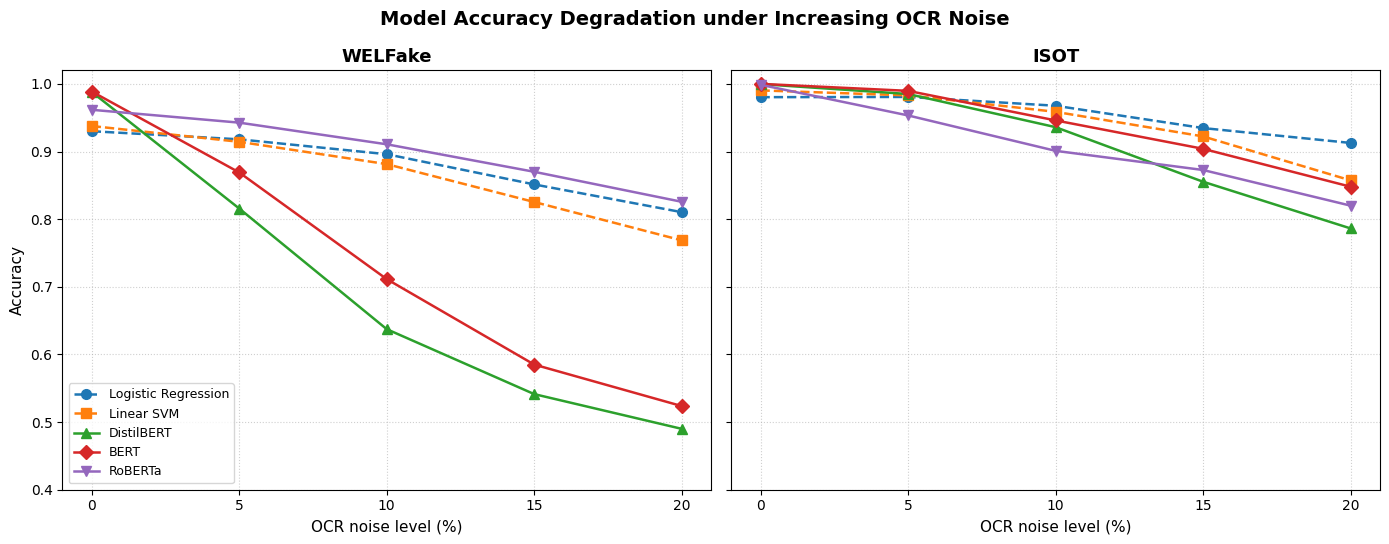

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# make sure both results are DataFrames
welfake_df = pd.DataFrame(results)
isot_df = pd.DataFrame(isot_results)

noise_x = [0, 5, 10, 15, 20]
models = ['Logistic Regression', 'Linear SVM', 'DistilBERT', 'BERT', 'RoBERTa']

# distinct styles so it works in greyscale too
styles = {
    'Logistic Regression': ('--', 'o'),
    'Linear SVM':          ('--', 's'),
    'DistilBERT':          ('-',  '^'),
    'BERT':                ('-',  'D'),
    'RoBERTa':             ('-',  'v'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, df, title in [(axes[0], welfake_df, 'WELFake'),
                      (axes[1], isot_df, 'ISOT')]:
    for model in models:
        sub = df[df['Model'] == model].sort_values('Noise')
        ls, mk = styles[model]
        ax.plot(sub['Noise'], sub['Accuracy'], ls, marker=mk,
                linewidth=1.8, markersize=7, label=model)
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('OCR noise level (%)', fontsize=11)
    ax.set_xticks(noise_x)
    ax.set_ylim(0.4, 1.02)
    ax.grid(True, linestyle=':', alpha=0.6)

axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=9, loc='lower left')

fig.suptitle('Model Accuracy Degradation under Increasing OCR Noise',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('noise_degradation.png', dpi=300, bbox_inches='tight')
plt.show()

##RQ3: SHAP

In [ ]:
!pip install -q shap

In [ ]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
import torch

shap_model = DistilBertForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/fyp_models/welfake_distilbert')
shap_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
shap_model.eval()
print("Model loaded")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded


In [ ]:
import shap
import numpy as np
from transformers import pipeline

# build a text-classification pipeline SHAP can use
device = 0 if torch.cuda.is_available() else -1
clf_pipeline = pipeline("text-classification", model=shap_model,
                        tokenizer=shap_tokenizer, device=device,
                        top_k=None, truncation=True, max_length=256)

# create the SHAP explainer
explainer = shap.Explainer(clf_pipeline)
print("SHAP explainer ready")

SHAP explainer ready


In [ ]:

example = ["Breaking news: government officials confirmed the new policy will take effect next month."]

shap_values = explainer(example)
shap.plots.text(shap_values)

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
# same sentence, but corrupted with 15% noise
noisy_example = [add_noise("Breaking news: government officials confirmed the new policy will take effect next month.", 0.15)]
print("Noisy text:", noisy_example[0])

shap_values_noisy = explainer(noisy_example)
shap.plots.text(shap_values_noisy)

Noisy text: Breqaing news:goverKnmenzt officilals coInfirmedD Bthe neL policyCwill take effec next moYth.


In [ ]:
ex2 = ["SHOCKING! Scientists reveal the government has been hiding the truth about vaccines for years!"]
print("CLEAN:")
shap.plots.text(explainer(ex2))

CLEAN:


In [ ]:
ex2_noisy = [add_noise("SHOCKING! Scientists reveal the government has been hiding the truth about vaccines for years!", 0.15)]
print("NOISY:", ex2_noisy[0])
shap.plots.text(explainer(ex2_noisy))

NOISY: SHOKING! ScintiPtsP revealthe government haA been hidNinJ tXectInuth about vaccines forL yCears!


In [ ]:
ex3 = ["The central bank announced on Tuesday that interest rates would remain unchanged following the quarterly review."]
print("CLEAN:")
shap.plots.text(explainer(ex3))

CLEAN:


In [ ]:
ex3_noisy = [add_noise("The central bank announced on Tuesday that interest rates would remain unchanged following the quarterly review.", 0.15)]
print("NOISY:", ex3_noisy[0])
shap.plots.text(explainer(ex3_noisy))

NOISY: TRhe centraNl bank wnTounced on Tesdayztha interest rates oul remainunZchfange following the quarterly preiw.


testing bug


In [ ]:
!pip install -q transformers
import torch
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
welfake = pd.read_csv("welfake_clean.csv")
print(welfake['label'].value_counts())

label
1    34620
0    28098
Name: count, dtype: int64


In [ ]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
model = DistilBertForSequenceClassification.from_pretrained('/content/drive/MyDrive/fyp_models/welfake_distilbert')
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model.eval()
print("Model loaded")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Model loaded


In [ ]:
# --- known REAL example (label==1) ---
real_example = welfake[welfake['label']==1]['content'].iloc[0]
inputs = tokenizer(real_example, truncation=True, padding=True, max_length=256, return_tensors="pt")
with torch.no_grad():
    out = model(**inputs)
pred = out.logits.argmax(-1).item()
print("TRUE label: REAL(1) | Model predicts:", pred, "->", "REAL" if pred==1 else "FAKE")

# --- known FAKE example (label==0) ---
fake_example = welfake[welfake['label']==0]['content'].iloc[0]
inputs = tokenizer(fake_example, truncation=True, padding=True, max_length=256, return_tensors="pt")
with torch.no_grad():
    out = model(**inputs)
pred = out.logits.argmax(-1).item()
print("TRUE label: FAKE(0) | Model predicts:", pred, "->", "REAL" if pred==1 else "FAKE")

TRUE label: REAL(1) | Model predicts: 1 -> REAL
TRUE label: FAKE(0) | Model predicts: 0 -> FAKE
